In [17]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import argparse, inspect, json, os, pickle, socket, subprocess, warnings, random, math, librosa, shutil, math, sys, importlib.util, shutil, tempfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from sklearn.metrics import accuracy_score, auc, balanced_accuracy_score, confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tensorboard.backend.event_processing import event_accumulator
from torch.amp import GradScaler
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from transformers import AutoConfig, AutoFeatureExtractor, AutoModel, get_linear_schedule_with_warmup

import commons, models, utils
from cough_datasets import CoughDatasets, CoughDatasetsCollate, CoughDatasetsProcessorCollate
from wrapper.wav2vec import Wav2VecWrapper
from wrapper.wavlm_plus import WavLMWrapper
from wrapper.whisper import WhisperWrapper

from IPython.display import display, Audio
import matplotlib.pyplot as plt

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


In [2]:
parser = argparse.ArgumentParser()
parser.add_argument("--model_name", type=str, default="try_wavlmlora_downstream")
args = parser.parse_args(["--model_name", "combined3dbbalv2_wavlmencoder_augmentv2_synthesis"])

model_dir = os.path.join("./logs", args.model_name)
config_save_path = os.path.join(model_dir, "config.json")
with open(config_save_path, "r") as f:
    data = f.read()

config = json.loads(data)
  
hps = utils.HParams(**config)
hps.model_dir = model_dir

BATCH_SIZE = hps.train.batch_size
ACCUMULATION_STEP = hps.train.accumulation_steps
assert (ACCUMULATION_STEP > 0) and (BATCH_SIZE % ACCUMULATION_STEP == 0)
cur_bs = BATCH_SIZE // ACCUMULATION_STEP

In [3]:
df_train = pd.read_csv('/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata.csv.train')
df_test = pd.read_csv('/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata.csv.val')

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

if hps.data.reorder_target:
    cols = hps.data.column_order
    df_train = df_train[cols]
    df_test = df_test[cols]

disease_codes = df_train[hps.data.target_column].unique().tolist()
class_frequencies = df_train[hps.data.target_column].value_counts().to_dict()
total_samples = len(df_train)
class_weights = {cls: total_samples / (len(disease_codes) * freq) if freq != 0 else 0 for cls, freq in class_frequencies.items()}
weights_list = [class_weights[cls] for cls in disease_codes]
class_weights_tensor = torch.tensor(weights_list, device='cuda', dtype=torch.float)
print(class_weights_tensor)

pickle_path = 'wav_stats.pickle'
if not os.path.exists(pickle_path):
    means, stds = [], []
    paths = df_train['path_file'].dropna().tolist()

    for path in tqdm(paths, desc="Processing WAV files", unit="file"):
        if not os.path.isfile(path):
            continue
        try:
            audio, _ = librosa.load(path, sr=None, mono=True)
            means.append(np.mean(audio))
            stds.append(np.std(audio))
        except Exception:
            continue

    stats = {
        "mean_db": float(np.mean(means)),
        "std_db": float(np.mean(stds))
    }

    with open(pickle_path, 'wb') as f:
        pickle.dump(stats, f)

# =============================================================
# SECTION: Setup Logger, Dataloader
# =============================================================
logger = utils.get_logger(hps.model_dir, filename='evaluate.log')
logger.info(hps)

collate_fn = CoughDatasetsCollate(hps.data.many_class)
train_dataset = CoughDatasets(df_train.values, hps.data, train=True)
val_dataset = CoughDatasets(df_test.values, hps.data, train=False)

train_loader = DataLoader(train_dataset, num_workers=28, shuffle=True, batch_size=cur_bs, pin_memory=True, drop_last=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, num_workers=28, shuffle=False, batch_size=hps.train.batch_size, pin_memory=True, drop_last=True, collate_fn=collate_fn)

# =============================================================
# SECTION: Setup Logger, Dataloader
# =============================================================
logger.info(f"Total Training Data : {len(df_train)}")
logger.info(f"======================================")
logger.info(f"✨ Training Input Shape: {next(iter(train_loader))[1][0].detach().cpu().numpy().shape}")
logger.info(f"✨ Loss: {hps.train.loss_function}")
logger.info(f"✨ Use Between Class Training: {hps.data.mix_audio}")
logger.info(f"✨ Use Augment: {hps.data.augment_data}")
logger.info(f"✨ Use Rawboost Augment: {hps.data.augment_rawboost}")
logger.info(f"✨ Padding Type: {hps.data.pad_types}")
logger.info(f"✨ Using Model: {hps.model.pooling_model}")
logger.info(f"======================================")

epoch_str = 1
global_step = 0
num_training_steps = len(train_loader) * 20
num_warmup_steps = int(0.01 * num_training_steps)  # 5% warmup

ssl_model_type = hps.model.ssl_model_type.lower()
ssl_model = None
if ssl_model_type == "wav2vec2":
    ssl_model = Wav2VecWrapper(hps.model)
    logger.info("✨ Using Wav2Vec2 SSL Model")
elif ssl_model_type == "wavlm":
    ssl_model = WavLMWrapper(hps.model)
    logger.info("✨ Using WavLM SSL Model")
elif ssl_model_type == "whisper":
    ssl_model = WhisperWrapper(hps.model)
    logger.info("✨ Using Whisper SSL Model")
elif ssl_model_type == "nonssl":
    logger.info("✨ Using Non-SSL Model")

if ssl_model != None:
    trainable_params = sum(p.numel() for p in ssl_model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in ssl_model.parameters())
    trainable_percentage = 100 * trainable_params / total_params if total_params > 0 else 0
    logger.info(f'Trainable params: {trainable_params} | Total params: {total_params} | Trainable%: {trainable_percentage:.2f}% | Size: {trainable_params/(1e6):.2f}M')
    hps.model.feature_dim = ssl_model.hidden_size_ssl
hps.model.spk_dim = 0 #len(participant_mapping_longi)

temp_path = tempfile.NamedTemporaryFile(suffix=".py", delete=False).name
shutil.copy(f"{model_dir}/model_net.py.bak", temp_path)
spec = importlib.util.spec_from_file_location("model_net", temp_path)
model_net = importlib.util.module_from_spec(spec)
sys.modules["model_net"] = model_net
spec.loader.exec_module(model_net)

pool_net = getattr(model_net, hps.model.pooling_model)
pool_model = pool_net(hps.model.feature_dim, **hps.model)

if ssl_model != None:
    ssl_model.model_pooling = pool_model
    pool_model = ssl_model

pool_model = pool_model.cuda()

_, _, _, _, epoch_str = utils.load_checkpoint(
    os.path.join(hps.model_dir, "best_pool.pth"),
    pool_model,
    None,
    None,
)


tensor([0.9980, 1.0020], device='cuda:0')
INFO:combined3dbbalv2_wavlmencoder_augmentv2_synthesis:{'train': {'use_cuda': True, 'log_interval': 20, 'seed': 1234, 'epochs': 10000, 'learning_rate': 5e-05, 'betas': [0.8, 0.99], 'eps': 1e-09, 'lr_decay': 0.999875, 'warmup_steps': 0, 'scheduler': 'noam', 'batch_size': 32, 'accumulation_steps': 1, 'fp16_run': False, 'loss_function': 'CE'}, 'data': {'max_value_norm': False, 'mean_std_norm': True, 'max_wav_value': 32768.0, 'sampling_rate': 16000, 'filter_length': 1024, 'hop_length': 256, 'win_length': 1024, 'n_mel_channels': 128, 'mel_fmin': 0.0, 'mel_fmax': 8000.0, 'saming_length': False, 'desired_length': 3.0, 'fade_samples_ratio': 16, 'pad_types': 'synthesis', 'acoustic_feature': False, 'feature_type': 'melspectogram', 'multimask_augment': False, 'tau': 0.15, 'nu': 0.15, 'num_masks': 4, 'augment_data': True, 'augment_rawboost': True, 'add_noise': False, 'mix_audio': False, 'many_class': 2, 'db_path': '', 'metadata_csv': 'metadata_cut_processe

In [ ]:
pool_model.eval()
all_wavnames, all_preds, all_labels, all_embeddings = [], [], [], []

with torch.no_grad():
    for _, (wav_names, audio, attention_masks, dse_ids, _) in enumerate(tqdm(train_loader, desc=f"Eval")):
        audio = audio.cuda(non_blocking=True).float().squeeze(1)
        attention_masks = attention_masks.cuda(non_blocking=True).float()
        dse_ids = dse_ids.cuda(non_blocking=True).float()

        raw_outputs = pool_model(audio, attention_mask=attention_masks)
        logits = raw_outputs["disease_logits"]
        preds = torch.argmax(logits, dim=1)
        labels = np.argmax(dse_ids.cpu().numpy(), axis=-1)

        all_wavnames.extend(wav_names)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels)
        all_embeddings.extend(raw_outputs["embeddings"].cpu().numpy())

    for _, (wav_names, audio, attention_masks, dse_ids, _) in enumerate(tqdm(val_loader, desc=f"Eval")):
        audio = audio.cuda(non_blocking=True).float().squeeze(1)
        attention_masks = attention_masks.cuda(non_blocking=True).float()
        dse_ids = dse_ids.cuda(non_blocking=True).float()

        raw_outputs = pool_model(audio, attention_mask=attention_masks)
        logits = raw_outputs["disease_logits"]
        preds = torch.argmax(logits, dim=1)
        labels = np.argmax(dse_ids.cpu().numpy(), axis=-1)

        all_wavnames.extend(wav_names)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels)
        all_embeddings.extend(raw_outputs["embeddings"].cpu().numpy())

print(accuracy_score(all_labels, all_preds))

df_test = pd.read_csv('/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata.csv.test')
df_test = df_test.rename(columns={"tb_status": "disease_status"})
df_test = df_test[hps.data.column_order]

val_dataset = CoughDatasets(df_test.values, hps.data, train=False)
val_loader = DataLoader(val_dataset, num_workers=28, shuffle=False, batch_size=hps.train.batch_size, pin_memory=True, drop_last=True, collate_fn=collate_fn)

with torch.no_grad():
    for _, (wav_names, audio, attention_masks, dse_ids, _) in enumerate(tqdm(val_loader, desc=f"Eval")):
        audio = audio.cuda(non_blocking=True).float().squeeze(1)
        attention_masks = attention_masks.cuda(non_blocking=True).float()
        dse_ids = dse_ids.cuda(non_blocking=True).float()

        raw_outputs = pool_model(audio, attention_mask=attention_masks)
        logits = raw_outputs["disease_logits"]
        preds = torch.argmax(logits, dim=1)
        labels = np.argmax(dse_ids.cpu().numpy(), axis=-1)

        all_wavnames.extend(wav_names)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels)
        all_embeddings.extend(raw_outputs["embeddings"].cpu().numpy())


all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_wavnames = np.array(all_wavnames)
all_embeddings = np.array(all_embeddings)

df_result = pd.DataFrame({
    'audio': all_wavnames,
    'label': all_labels,
    'pred': all_preds,
    'embeddings': all_embeddings.tolist(),
})

print(accuracy_score(all_labels, all_preds))

from sliceguard import SliceGuard
from sklearn.metrics import accuracy_score

sg = SliceGuard()
issues = sg.find_issues(df_result, features=["audio"], y="label", y_pred="pred", 
                        metric=accuracy_score, 
                        #embedding_models={"wavname": "MIT/ast-finetuned-audioset-10-10-0.4593"},
                        precomputed_embeddings={"audio": all_embeddings},
                        min_support=3,
                        min_drop=0.4)
report_df, spotlight_data_issues, spotlight_dtypes, spotlight_layout = sg.report(no_browser=True)

combined_selected_rows = []
for now_data_issue in spotlight_data_issues:
    selected_rows = df_result.iloc[now_data_issue.rows]
    combined_selected_rows.append(selected_rows)

final_selected_df = pd.concat(combined_selected_rows, ignore_index=True)
final_selected_df['audio'] = final_selected_df['audio'].str.replace(hps.data.db_path, "", regex=False)
final_selected_df = final_selected_df.drop(columns=["embeddings"])
final_selected_df = final_selected_df.rename(columns={"audio": "path_file"})

from renumics import spotlight
spotlight.show(df_result.reset_index(), issues=spotlight_data_issues, layout=spotlight_layout)

Eval: 100%|██████████| 72/72 [00:07<00:00,  9.92it/s]


0.7221362229102167
2.780925751721952e-05


Eval: 100%|██████████| 72/72 [00:07<00:00,  9.85it/s]


0.7240506329113924
Using precomputed embeddings.
Pre-reducing feature audio in mode native.
Using op mix ratio 0.8.
Using num dimensions 32.
The overall metric value is 0.7240506329113924
You didn't specify metric_mode parameter. Using max as default.
Detecting issues for criteria n_slices=None, criterion=None, min_drop=0.4, min_support=3.
Identified 295 problematic slices.


In [24]:
final_selected_df = final_selected_df.drop(columns=["embeddings"])

In [28]:
final_selected_df.to_csv("/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/probleatics.csv", index=False)

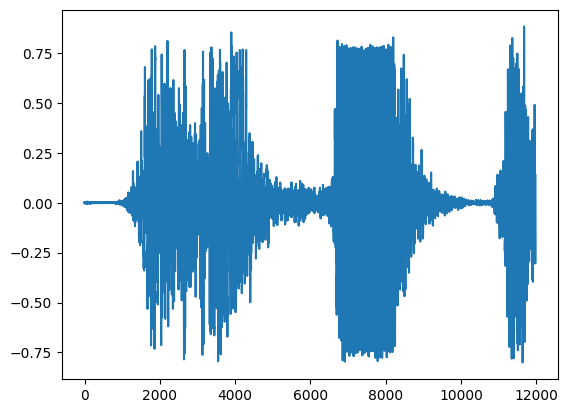

In [22]:
sample_data = final_selected_df.sample(n=1).values[0][0]
audio_original = utils.load_audio_sample(sample_data, train_dataset.sampling_rate, train_dataset.saming_length, 
                                train_dataset.desired_length, fade_samples_ratio=train_dataset.fade_samples_ratio, 
                                pad_types="zeros").squeeze().numpy()

display(Audio(audio_original, rate=train_dataset.sampling_rate))
plt.plot(audio_original)

In [ ]:
pool_model.eval()
all_wavnames, all_preds, all_labels, all_embeddings = [], [], [], []

with torch.no_grad():
    for _, (wav_names, audio, attention_masks, dse_ids, _) in enumerate(tqdm(train_loader, desc=f"Eval")):
        audio = audio.cuda(non_blocking=True).float().squeeze(1)
        attention_masks = attention_masks.cuda(non_blocking=True).float()
        dse_ids = dse_ids.cuda(non_blocking=True).float()

        raw_outputs = pool_model(audio, attention_mask=attention_masks)
        logits = raw_outputs["disease_logits"]
        preds = torch.argmax(logits, dim=1)
        labels = np.argmax(dse_ids.cpu().numpy(), axis=-1)

        all_wavnames.extend(wav_names)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels)
        all_embeddings.extend(raw_outputs["embeddings"].cpu().numpy())

    for _, (wav_names, audio, attention_masks, dse_ids, _) in enumerate(tqdm(val_loader, desc=f"Eval")):
        audio = audio.cuda(non_blocking=True).float().squeeze(1)
        attention_masks = attention_masks.cuda(non_blocking=True).float()
        dse_ids = dse_ids.cuda(non_blocking=True).float()

        raw_outputs = pool_model(audio, attention_mask=attention_masks)
        logits = raw_outputs["disease_logits"]
        preds = torch.argmax(logits, dim=1)
        labels = np.argmax(dse_ids.cpu().numpy(), axis=-1)

        all_wavnames.extend(wav_names)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels)
        all_embeddings.extend(raw_outputs["embeddings"].cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_wavnames = np.array(all_wavnames)
all_embeddings = np.array(all_embeddings)

df_result = pd.DataFrame({
    'wavname': all_wavnames,
    'label': all_labels,
    'pred': all_preds
})

print(accuracy_score(all_labels, all_preds))

from sliceguard import SliceGuard
from sklearn.metrics import accuracy_score

sg = SliceGuard()
issues = sg.find_issues(df_result, features=["wavname"], y="label", y_pred="pred", metric=accuracy_score, precomputed_embeddings={"wavname": all_embeddings})
report_df, spotlight_data_issues, spotlight_dtypes, spotlight_layout = sg.report(no_browser=True)

combined_selected_rows = []

for now_data_issue in spotlight_data_issues:
    selected_rows = df_result.iloc[now_data_issue.rows]
    combined_selected_rows.append(selected_rows)

final_selected_df = pd.concat(combined_selected_rows, ignore_index=True)
final_selected_df['wavname'] = final_selected_df['wavname'].str.replace(hps.data.db_path, "", regex=False)

from renumics import spotlight
spotlight.show(df_result.reset_index(), issues=spotlight_data_issues, layout=spotlight_layout)